In [1]:
"""
Graph-Based Physics-Informed Analytics for Production Loss Detection
--------------------------------------------------------------------

This project develops an intelligent data-driven framework for detecting
production losses, anomalies, and operational inefficiencies in oil and gas
fields using the publicly available Volve dataset.

The workflow integrates:
- Time-series production analytics (oil, gas, water)
- Physics-informed constraints derived from reservoir inflow performance
  relationships (e.g., Vogel IPR)
- Machine learning models for anomaly and loss detection
- Network-aware abstractions to support future graph-based modeling of
  interconnected wells and surface facilities

Unlike conventional production forecasting, the focus is on identifying
hidden production losses, flow inconsistencies, and abnormal operating
conditions that impact asset performance and revenue assurance.

This study supports digital oilfield operations, production optimization,
and energy efficiency, aligning with SPE themes on AI, Big Data, and
Oilfield Digitalization.
"""

import os
import warnings
from datetime import datetime

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# --------------------------------------------------
# Global configuration
# --------------------------------------------------
warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10, 5)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Project directories
BASE_DIR = os.getcwd()
MODEL_DIR = os.path.join(BASE_DIR, "models")
DATA_DIR = os.path.join(BASE_DIR, "processed")
FIG_DIR = os.path.join(BASE_DIR, "figures")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

print("=" * 90)
print("GRAPH-BASED PHYSICS-INFORMED PRODUCTION LOSS ANALYTICS")
print("Oil & Gas Field Case Study (Volve Dataset)")
print("=" * 90)
print(f"Execution started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("Objective: Detect production losses and anomalous behavior\n")


GRAPH-BASED PHYSICS-INFORMED PRODUCTION LOSS ANALYTICS
Oil & Gas Field Case Study (Volve Dataset)
Execution started: 2026-01-13 21:33:46
Objective: Detect production losses and anomalous behavior



In [2]:
# ==========================================
# Step 1: Load and Inspect Volve Production Data
# ==========================================

import pandas as pd

# Path to your file — update this if it's in a subfolder
file_path = "Volve production data.xlsx"

# Read Excel (if it has multiple sheets, we can list them)
xls = pd.ExcelFile(file_path)
print("Available sheets:", xls.sheet_names)

# If you already know which sheet (e.g., 'Production Data'), load it:
df = pd.read_excel(xls, xls.sheet_names[0])

# Display basic info
print("\n--- Data Overview ---")
print(df.head())
print("\n--- Info ---")
print(df.info())
print("\n--- Missing Values ---")
print(df.isna().sum())

# check columns
print("\nColumns in dataset:", df.columns.tolist())

# -----------------------------------------------------
# Column verification
# -----------------------------------------------------
print("\n--- Available Features ---")
for col in df.columns:
    print(f"- {col}")

# -----------------------------------------------------
# Temporal sanity check (important for time-series)
# -----------------------------------------------------
if "DATE" in df.columns or "date" in df.columns:
    date_col = "DATE" if "DATE" in df.columns else "date"
    df[date_col] = pd.to_datetime(df[date_col])
    print(f"\nDate range: {df[date_col].min()} → {df[date_col].max()}")

Available sheets: ['Daily Production Data', 'Monthly Production Data']

--- Data Overview ---
     DATEPRD WELL_BORE_CODE  NPD_WELL_BORE_CODE NPD_WELL_BORE_NAME  \
0 2014-04-07  NO 15/9-F-1 C                7405         15/9-F-1 C   
1 2014-04-08  NO 15/9-F-1 C                7405         15/9-F-1 C   
2 2014-04-09  NO 15/9-F-1 C                7405         15/9-F-1 C   
3 2014-04-10  NO 15/9-F-1 C                7405         15/9-F-1 C   
4 2014-04-11  NO 15/9-F-1 C                7405         15/9-F-1 C   

   NPD_FIELD_CODE NPD_FIELD_NAME  NPD_FACILITY_CODE NPD_FACILITY_NAME  \
0         3420717          VOLVE             369304    MÆRSK INSPIRER   
1         3420717          VOLVE             369304    MÆRSK INSPIRER   
2         3420717          VOLVE             369304    MÆRSK INSPIRER   
3         3420717          VOLVE             369304    MÆRSK INSPIRER   
4         3420717          VOLVE             369304    MÆRSK INSPIRER   

   ON_STREAM_HRS  AVG_DOWNHOLE_PRESSURE  ...  

In [3]:
# ==========================================
# Step 2: Missing Values & Statistical Summary
# ==========================================

def per_missing(df):
    """
    Calculate the percentage of missing values for each column in the DataFrame.
    """
    total_rows = len(df)
    missing_df = df.isna().sum().to_frame(name='Missing Count')
    missing_df['% Missing'] = (missing_df['Missing Count'] / total_rows) * 100
    missing_df = missing_df[missing_df['Missing Count'] > 0]  # show only columns with missing values
    return missing_df.sort_values(by='% Missing', ascending=False)

# Display missing values summary
missing_summary = per_missing(df)
print("\n==============================")
print("📊 Missing Values Summary")
print("==============================")
if missing_summary.empty:
    print("No missing values detected.")
else:
    print(missing_summary)

# Display statistical summary
print("\n==============================")
print("📈 Statistical Summary")
print("==============================")
print(df.describe(include='all').T)



📊 Missing Values Summary
                          Missing Count  % Missing
BORE_WI_VOL                        9928  63.502622
AVG_ANNULUS_PRESS                  7744  49.533069
AVG_CHOKE_SIZE_P                   6715  42.951260
AVG_DOWNHOLE_PRESSURE              6654  42.561085
AVG_DOWNHOLE_TEMPERATURE           6654  42.561085
AVG_DP_TUBING                      6654  42.561085
AVG_WHT_P                          6488  41.499296
AVG_WHP_P                          6479  41.441730
AVG_CHOKE_UOM                      6473  41.403352
BORE_OIL_VOL                       6473  41.403352
BORE_GAS_VOL                       6473  41.403352
BORE_WAT_VOL                       6473  41.403352
DP_CHOKE_SIZE                       294   1.880517
ON_STREAM_HRS                       285   1.822950

📈 Statistical Summary
                            count unique             top   freq  \
DATEPRD                     15634    NaN             NaN    NaN   
WELL_BORE_CODE              15634      7  NO 15/9-F-

In [4]:
# =====================================================
# Step 2: Engineering-Aware Missing Value Handling (FINAL)
# =====================================================

import numpy as np

# -----------------------------------------------------
# Ensure datetime ordering
# -----------------------------------------------------
df["DATEPRD"] = pd.to_datetime(df["DATEPRD"])
df = df.sort_values(["WELL_BORE_CODE", "DATEPRD"]).reset_index(drop=True)

# -----------------------------------------------------
# A. ON_STREAM_HRS
# -----------------------------------------------------
df["ON_STREAM_HRS"] = df["ON_STREAM_HRS"].fillna(0)

# -----------------------------------------------------
# B. Production volumes
# Rule: OFF-STREAM → ZERO production
# -----------------------------------------------------
prod_cols = [
    "BORE_OIL_VOL",
    "BORE_GAS_VOL",
    "BORE_WAT_VOL",
    "BORE_WI_VOL"
]

for col in prod_cols:
    df[col] = np.where(df["ON_STREAM_HRS"] == 0, 0, df[col])

# Time-aware interpolation per well (SAFE)
df[prod_cols] = (
    df.groupby("WELL_BORE_CODE")[prod_cols]
      .transform(lambda x: x.interpolate(limit=3))
)

# -----------------------------------------------------
# C. Pressure & temperature
# Preserve missingness + short forward-fill
# -----------------------------------------------------
pressure_cols = [
    "AVG_DOWNHOLE_PRESSURE",
    "AVG_DOWNHOLE_TEMPERATURE",
    "AVG_DP_TUBING",
    "AVG_ANNULUS_PRESS",
    "AVG_WHP_P",
    "AVG_WHT_P"
]

for col in pressure_cols:
    df[f"{col}_missing"] = df[col].isna().astype(int)
    df[col] = (
        df.groupby("WELL_BORE_CODE")[col]
          .transform(lambda x: x.ffill(limit=5))
    )

# -----------------------------------------------------
# D. Choke variables
# -----------------------------------------------------
choke_cols = ["AVG_CHOKE_SIZE_P", "DP_CHOKE_SIZE"]

for col in choke_cols:
    df[f"{col}_missing"] = df[col].isna().astype(int)
    df[col] = (
        df.groupby("WELL_BORE_CODE")[col]
          .transform(lambda x: x.ffill())
    )

# -----------------------------------------------------
# Final validation
# -----------------------------------------------------
print("\n--- Remaining Missing Values (Top 15) ---")
print(df.isna().sum().sort_values(ascending=False).head(15))

print("\nFinal dataset shape:", df.shape)



--- Remaining Missing Values (Top 15) ---
BORE_WI_VOL                         7662
AVG_ANNULUS_PRESS                   7519
AVG_DOWNHOLE_PRESSURE               6635
AVG_DOWNHOLE_TEMPERATURE            6635
AVG_DP_TUBING                       6635
AVG_CHOKE_SIZE_P                    6519
AVG_WHT_P                           6481
AVG_CHOKE_UOM                       6473
AVG_WHP_P                           6472
BORE_OIL_VOL                        5054
BORE_GAS_VOL                        5054
BORE_WAT_VOL                        5054
DP_CHOKE_SIZE                        244
AVG_DOWNHOLE_TEMPERATURE_missing       0
AVG_DOWNHOLE_PRESSURE_missing          0
dtype: int64

Final dataset shape: (15634, 32)


In [5]:
# -----------------------------------------------------
# Final production sanity fix
# -----------------------------------------------------
prod_cols = ["BORE_OIL_VOL", "BORE_GAS_VOL", "BORE_WAT_VOL"]

for col in prod_cols:
    df[col] = np.where(
        (df["ON_STREAM_HRS"] > 0) & (df[col].isna()),
        0,
        df[col]
    )

print("\nProduction missing after fix:")
print(df[prod_cols].isna().sum())



Production missing after fix:
BORE_OIL_VOL    0
BORE_GAS_VOL    0
BORE_WAT_VOL    0
dtype: int64


In [6]:
# -----------------------------------------------------
# Step: Drop high-missing, low-impact features
# -----------------------------------------------------

cols_to_drop = [
    "AVG_ANNULUS_PRESS",
    "AVG_DP_TUBING",
    "AVG_CHOKE_SIZE_P",
    "AVG_CHOKE_UOM",
    "DP_CHOKE_SIZE",
    "AVG_WHT_P",
    "AVG_WHP_P"
]

# Drop only if they exist (safety)
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

print("Dropped columns:")
print(cols_to_drop)

print("\nFinal dataset shape:", df.shape)
print("\nRemaining missing values:")
print(df.isna().sum().sort_values(ascending=False).head(10))


Dropped columns:
['AVG_ANNULUS_PRESS', 'AVG_DP_TUBING', 'AVG_CHOKE_SIZE_P', 'AVG_CHOKE_UOM', 'DP_CHOKE_SIZE', 'AVG_WHT_P', 'AVG_WHP_P']

Final dataset shape: (15634, 25)

Remaining missing values:
BORE_WI_VOL                         7662
AVG_DOWNHOLE_PRESSURE               6635
AVG_DOWNHOLE_TEMPERATURE            6635
DATEPRD                                0
AVG_CHOKE_SIZE_P_missing               0
AVG_WHT_P_missing                      0
AVG_WHP_P_missing                      0
AVG_ANNULUS_PRESS_missing              0
AVG_DP_TUBING_missing                  0
AVG_DOWNHOLE_TEMPERATURE_missing       0
dtype: int64


In [7]:
import numpy as np
import pandas as pd

# Ensure ordering
df["DATEPRD"] = pd.to_datetime(df["DATEPRD"])
df = df.sort_values(["WELL_BORE_CODE", "DATEPRD"]).reset_index(drop=True)

# --- Missing flags for key sensors ---
sensor_cols = ["AVG_DOWNHOLE_PRESSURE", "AVG_DOWNHOLE_TEMPERATURE", "BORE_WI_VOL"]
for c in sensor_cols:
    df[f"{c}_missing"] = df[c].isna().astype(np.int8)

# --- Time-based split (example: last 20% time as test) ---
cutoff = df["DATEPRD"].quantile(0.8)
train_df = df[df["DATEPRD"] <= cutoff].copy()
test_df  = df[df["DATEPRD"] > cutoff].copy()

# --- Conservative imputation on train ONLY ---
# Per-well medians from TRAIN
well_medians = (
    train_df.groupby("WELL_BORE_CODE")[["AVG_DOWNHOLE_PRESSURE","AVG_DOWNHOLE_TEMPERATURE","BORE_WI_VOL"]]
    .median()
)

def apply_impute(split_df):
    split_df = split_df.copy()
    for col in ["AVG_DOWNHOLE_PRESSURE","AVG_DOWNHOLE_TEMPERATURE","BORE_WI_VOL"]:
        # map per-well median; if a well never had values in train, fallback to global median (train)
        global_med = train_df[col].median()
        split_df["_well_med"] = split_df["WELL_BORE_CODE"].map(well_medians[col])
        split_df[col] = split_df[col].fillna(split_df["_well_med"]).fillna(global_med)
        split_df.drop(columns=["_well_med"], inplace=True)
    return split_df

train_df = apply_impute(train_df)
test_df  = apply_impute(test_df)

print("Remaining NaNs train:", train_df.isna().sum().sort_values(ascending=False).head(10))
print("Remaining NaNs test:", test_df.isna().sum().sort_values(ascending=False).head(10))


Remaining NaNs train: DATEPRD                             0
WELL_BORE_CODE                      0
DP_CHOKE_SIZE_missing               0
AVG_CHOKE_SIZE_P_missing            0
AVG_WHT_P_missing                   0
AVG_WHP_P_missing                   0
AVG_ANNULUS_PRESS_missing           0
AVG_DP_TUBING_missing               0
AVG_DOWNHOLE_TEMPERATURE_missing    0
AVG_DOWNHOLE_PRESSURE_missing       0
dtype: int64
Remaining NaNs test: DATEPRD                             0
WELL_BORE_CODE                      0
DP_CHOKE_SIZE_missing               0
AVG_CHOKE_SIZE_P_missing            0
AVG_WHT_P_missing                   0
AVG_WHP_P_missing                   0
AVG_ANNULUS_PRESS_missing           0
AVG_DP_TUBING_missing               0
AVG_DOWNHOLE_TEMPERATURE_missing    0
AVG_DOWNHOLE_PRESSURE_missing       0
dtype: int64


In [8]:
# ============================================================
# FEATURE ENGINEERING: Oil & Gas Production Network (FINAL)
# Purpose:
# - Enhance anomaly, loss, and inefficiency detection
# - Preserve operational realism
# - Avoid data leakage
# ============================================================

import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# ------------------------------------------------------------
# Safety constant (prevents division by zero)
# ------------------------------------------------------------
eps = 1e-6

# ------------------------------------------------------------
# Ensure proper datetime ordering (CRITICAL for time features)
# ------------------------------------------------------------
df["DATEPRD"] = pd.to_datetime(df["DATEPRD"])
df = df.sort_values(["WELL_BORE_CODE", "DATEPRD"]).reset_index(drop=True)

# ============================================================
# 1️⃣ RATE NORMALIZATION (Production per operating hour)
# Why:
# - Separates downtime effects from real performance issues
# ============================================================
df["OIL_RATE"] = df["BORE_OIL_VOL"] / (df["ON_STREAM_HRS"] + eps)
df["GAS_RATE"] = df["BORE_GAS_VOL"] / (df["ON_STREAM_HRS"] + eps)
df["WAT_RATE"] = df["BORE_WAT_VOL"] / (df["ON_STREAM_HRS"] + eps)

# ============================================================
# 2️⃣ TEMPORAL DYNAMICS (Past-only, per-well)
# Why:
# - Detect sudden drops, gradual degradation, instability
# ============================================================
rate_cols = ["OIL_RATE", "GAS_RATE", "WAT_RATE"]

# First-order change (trend / shock detection)
for col in rate_cols:
    df[f"{col}_delta"] = (
        df.groupby("WELL_BORE_CODE")[col]
          .diff()
          .fillna(0)
    )

# Rolling statistics (short-term memory)
windows = [3, 6]  # months (or timesteps)

for col in rate_cols:
    for w in windows:
        df[f"{col}_roll_mean_{w}"] = (
            df.groupby("WELL_BORE_CODE")[col]
              .transform(lambda x: x.rolling(w, min_periods=1).mean())
        )
        df[f"{col}_roll_std_{w}"] = (
            df.groupby("WELL_BORE_CODE")[col]
              .transform(lambda x: x.rolling(w, min_periods=1).std())
        )

# ============================================================
# 3️⃣ PHYSICS-INSPIRED FEATURES (Reviewer-friendly)
# ============================================================

# --- Gas-Oil Ratio (GOR)
# Sudden GOR spikes → leaks, gas breakthrough, valve issues
df["GOR"] = df["BORE_GAS_VOL"] / (df["BORE_OIL_VOL"] + eps)
df["GOR_delta"] = (
    df.groupby("WELL_BORE_CODE")["GOR"]
      .diff()
      .fillna(0)
)

# --- Water Cut
# Rising water cut → coning, water breakthrough, integrity issues
df["WATER_CUT"] = df["BORE_WAT_VOL"] / (
    df["BORE_OIL_VOL"] + df["BORE_WAT_VOL"] + eps
)

# --- Pressure-to-production proxy
# High pressure but low oil → restriction, blockage, inefficiency
df["PRESSURE_PER_OIL"] = df["AVG_DOWNHOLE_PRESSURE"] / (
    df["BORE_OIL_VOL"] + eps
)

# ============================================================
# 4️⃣ OPERATIONAL CONSISTENCY FLAGS (Hard anomalies)
# ============================================================

# Producing time exists but zero oil & gas
df["PRODUCING_ZERO"] = (
    (df["ON_STREAM_HRS"] > 0) &
    (df["BORE_OIL_VOL"] == 0) &
    (df["BORE_GAS_VOL"] == 0)
).astype(int)

# Pressure recorded but no production
df["PRESSURE_NO_FLOW"] = (
    (df["AVG_DOWNHOLE_PRESSURE"] > 0) &
    (df["BORE_OIL_VOL"] == 0)
).astype(int)

# ============================================================
# 5️⃣ CATEGORICAL ENCODING (Compact, GNN-safe)
# Why:
# - Avoid high-dimensional one-hot encoding
# ============================================================
for col in ["WELL_TYPE", "FLOW_KIND"]:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

# ============================================================
# 6️⃣ FINAL SANITY CHECK (MANDATORY)
# ============================================================
print("✅ Feature engineering completed")
print("Final dataset shape:", df.shape)

print("\nSample of engineered features:")
print(df[
    [
        "OIL_RATE", "OIL_RATE_delta",
        "GOR", "WATER_CUT",
        "PRESSURE_PER_OIL",
        "PRODUCING_ZERO", "PRESSURE_NO_FLOW"
    ]
].head())


✅ Feature engineering completed
Final dataset shape: (15634, 50)

Sample of engineered features:
   OIL_RATE  OIL_RATE_delta  GOR  WATER_CUT  PRESSURE_PER_OIL  PRODUCING_ZERO  \
0       0.0             0.0  0.0        0.0               0.0               0   
1       0.0             0.0  0.0        0.0               0.0               0   
2       0.0             0.0  0.0        0.0               0.0               0   
3       0.0             0.0  0.0        0.0               0.0               0   
4       0.0             0.0  0.0        0.0       310376140.0               0   

   PRESSURE_NO_FLOW  
0                 0  
1                 0  
2                 0  
3                 0  
4                 1  


🔹 Dataset overview
(15634, 50)

Columns:
['DATEPRD', 'WELL_BORE_CODE', 'NPD_WELL_BORE_CODE', 'NPD_WELL_BORE_NAME', 'NPD_FIELD_CODE', 'NPD_FIELD_NAME', 'NPD_FACILITY_CODE', 'NPD_FACILITY_NAME', 'ON_STREAM_HRS', 'AVG_DOWNHOLE_PRESSURE', 'AVG_DOWNHOLE_TEMPERATURE', 'BORE_OIL_VOL', 'BORE_GAS_VOL', 'BORE_WAT_VOL', 'BORE_WI_VOL', 'FLOW_KIND', 'WELL_TYPE', 'AVG_DOWNHOLE_PRESSURE_missing', 'AVG_DOWNHOLE_TEMPERATURE_missing', 'AVG_DP_TUBING_missing', 'AVG_ANNULUS_PRESS_missing', 'AVG_WHP_P_missing', 'AVG_WHT_P_missing', 'AVG_CHOKE_SIZE_P_missing', 'DP_CHOKE_SIZE_missing', 'BORE_WI_VOL_missing', 'OIL_RATE', 'GAS_RATE', 'WAT_RATE', 'OIL_RATE_delta', 'GAS_RATE_delta', 'WAT_RATE_delta', 'OIL_RATE_roll_mean_3', 'OIL_RATE_roll_std_3', 'OIL_RATE_roll_mean_6', 'OIL_RATE_roll_std_6', 'GAS_RATE_roll_mean_3', 'GAS_RATE_roll_std_3', 'GAS_RATE_roll_mean_6', 'GAS_RATE_roll_std_6', 'WAT_RATE_roll_mean_3', 'WAT_RATE_roll_std_3', 'WAT_RATE_roll_mean_6', 'WAT_RATE_roll_std_6', 'GOR', 'GOR_delta', 'WATER_CUT', 'P

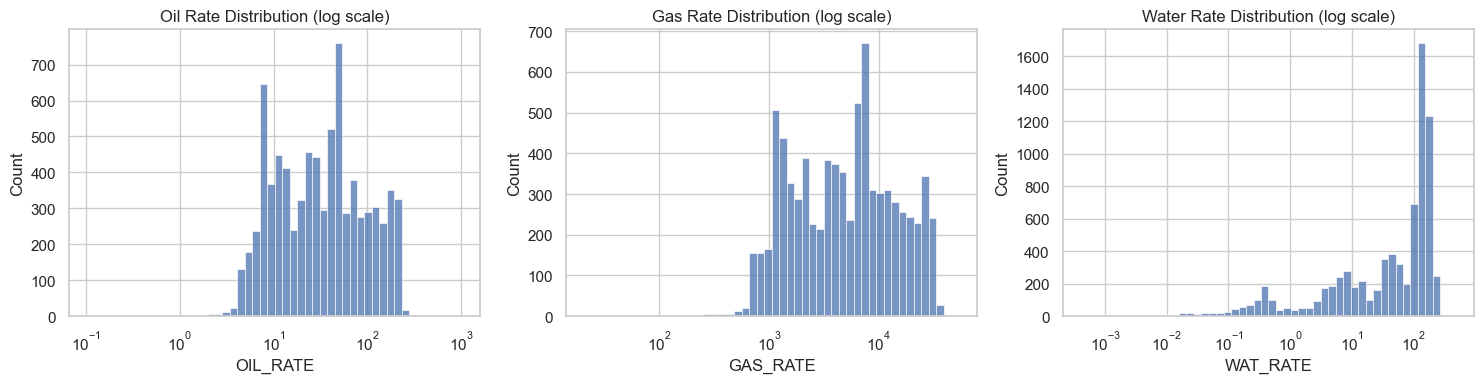

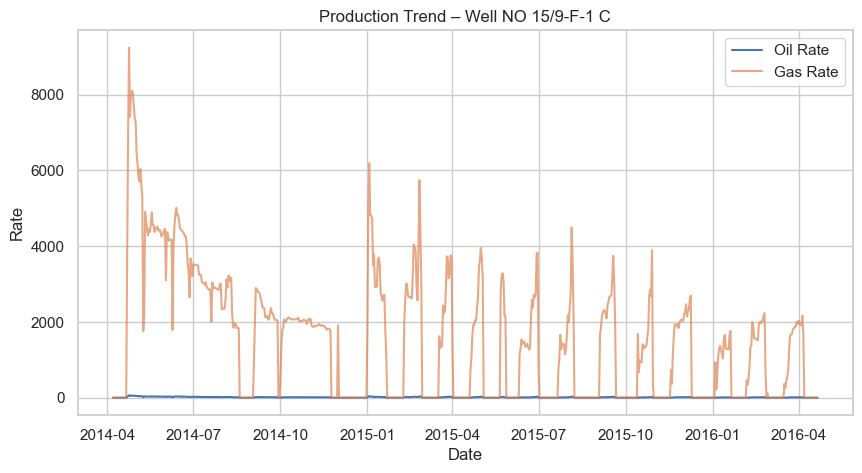

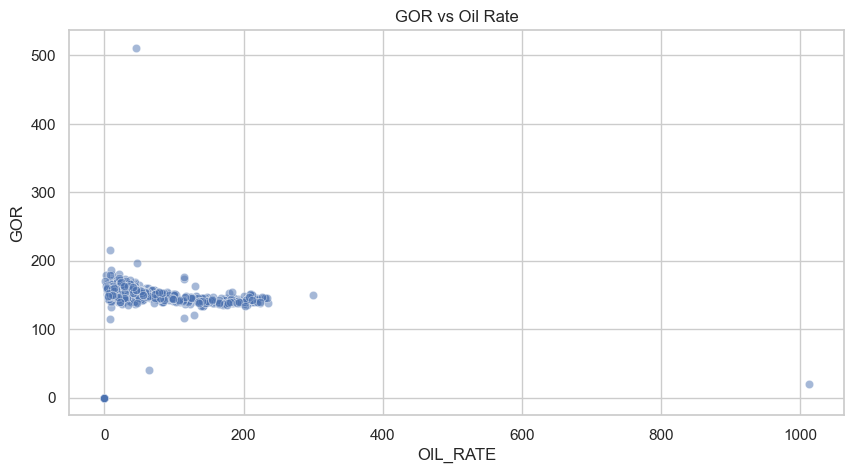


🔹 Anomaly flag frequencies:
PRODUCING_ZERO: 0.345
PRESSURE_NO_FLOW: 0.047

🔹 Sensor missingness rates:
AVG_ANNULUS_PRESS_missing           0.495331
BORE_WI_VOL_missing                 0.490086
AVG_CHOKE_SIZE_P_missing            0.429513
AVG_DP_TUBING_missing               0.425611
AVG_DOWNHOLE_PRESSURE_missing       0.424396
AVG_DOWNHOLE_TEMPERATURE_missing    0.424396
AVG_WHT_P_missing                   0.414993
AVG_WHP_P_missing                   0.414417
DP_CHOKE_SIZE_missing               0.018805
dtype: float64


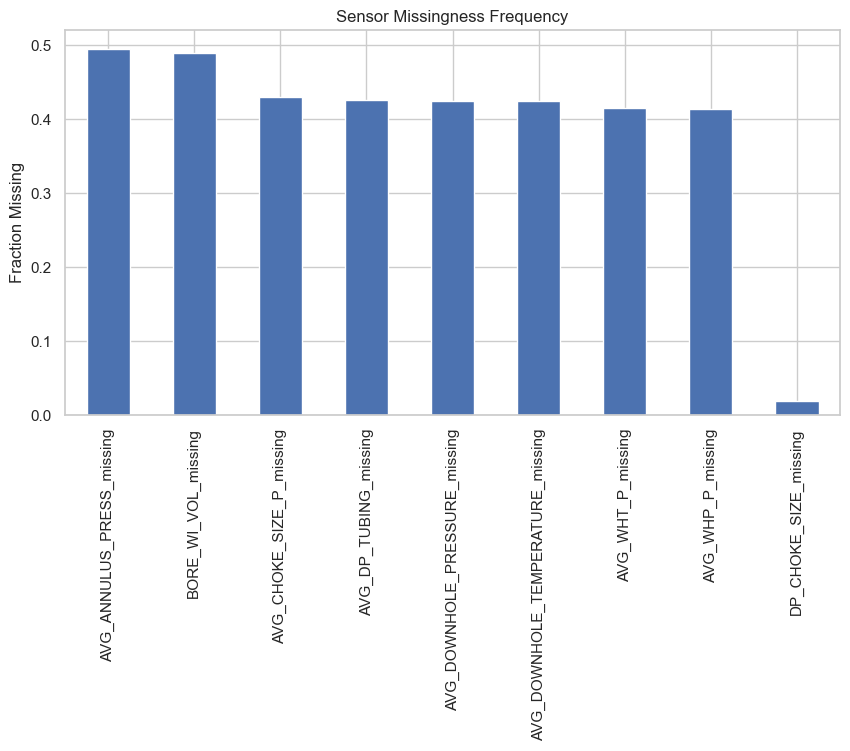

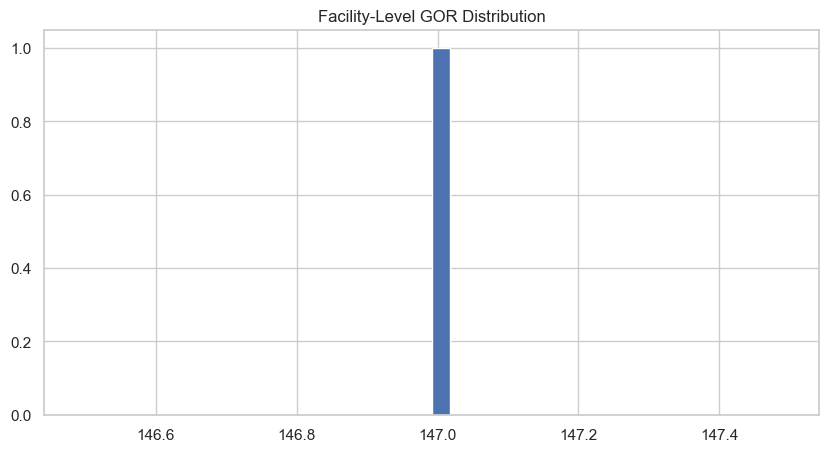


✅ EDA completed successfully


In [9]:
# ============================================================
# EXPLORATORY DATA ANALYSIS (EDA)
# Purpose:
# - Understand production behavior & variability
# - Validate engineered features
# - Identify anomaly-prone patterns
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# Global plot settings (clean, paper-ready)
# ------------------------------------------------------------
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# ============================================================
# 1️⃣ BASIC DATA OVERVIEW
# ============================================================
print("🔹 Dataset overview")
print(df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\n🔹 Summary statistics (key numeric features)")
key_numeric = [
    "BORE_OIL_VOL", "BORE_GAS_VOL", "BORE_WAT_VOL",
    "OIL_RATE", "GAS_RATE", "WAT_RATE",
    "GOR", "WATER_CUT",
    "AVG_DOWNHOLE_PRESSURE",
    "ON_STREAM_HRS"
]
print(df[key_numeric].describe().T)

# ============================================================
# 2️⃣ PRODUCTION DISTRIBUTIONS (Heavy tails = anomaly potential)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df["OIL_RATE"], bins=50, ax=axes[0], log_scale=True)
axes[0].set_title("Oil Rate Distribution (log scale)")

sns.histplot(df["GAS_RATE"], bins=50, ax=axes[1], log_scale=True)
axes[1].set_title("Gas Rate Distribution (log scale)")

sns.histplot(df["WAT_RATE"], bins=50, ax=axes[2], log_scale=True)
axes[2].set_title("Water Rate Distribution (log scale)")

plt.tight_layout()
plt.show()

# ============================================================
# 3️⃣ TEMPORAL BEHAVIOR (Single-well sanity check)
# Why:
# - Shows drops, instability, regime changes
# ============================================================
sample_well = df["WELL_BORE_CODE"].iloc[0]

well_df = df[df["WELL_BORE_CODE"] == sample_well]

plt.plot(well_df["DATEPRD"], well_df["OIL_RATE"], label="Oil Rate")
plt.plot(well_df["DATEPRD"], well_df["GAS_RATE"], label="Gas Rate", alpha=0.7)
plt.title(f"Production Trend – Well {sample_well}")
plt.xlabel("Date")
plt.ylabel("Rate")
plt.legend()
plt.show()

# ============================================================
# 4️⃣ ENGINEERED FEATURE VALIDATION
# A. GOR vs Oil Rate (physics consistency)
# ============================================================
sns.scatterplot(
    x="OIL_RATE",
    y="GOR",
    data=df.sample(2000, random_state=42),
    alpha=0.5
)
plt.title("GOR vs Oil Rate")
plt.show()

# ============================================================
# 5️⃣ OPERATIONAL ANOMALY FLAGS
# How often do hard anomalies occur?
# ============================================================
flag_cols = ["PRODUCING_ZERO", "PRESSURE_NO_FLOW"]

print("\n🔹 Anomaly flag frequencies:")
for col in flag_cols:
    print(f"{col}: {df[col].mean():.3f}")

# ============================================================
# 6️⃣ SENSOR AVAILABILITY ANALYSIS
# Missingness as a signal
# ============================================================
missing_cols = [c for c in df.columns if c.endswith("_missing")]

missing_rates = df[missing_cols].mean().sort_values(ascending=False)

print("\n🔹 Sensor missingness rates:")
print(missing_rates)

missing_rates.plot(kind="bar")
plt.title("Sensor Missingness Frequency")
plt.ylabel("Fraction Missing")
plt.show()

# ============================================================
# 7️⃣ FACILITY-LEVEL AGGREGATION CHECK
# Why:
# - Loss/theft often emerges at aggregation points
# ============================================================
facility_prod = (
    df.groupby("NPD_FACILITY_CODE")[["BORE_OIL_VOL", "BORE_GAS_VOL"]]
      .sum()
)

facility_prod["GOR"] = (
    facility_prod["BORE_GAS_VOL"] /
    (facility_prod["BORE_OIL_VOL"] + 1e-6)
)

facility_prod["GOR"].hist(bins=40)
plt.title("Facility-Level GOR Distribution")
plt.show()

# ============================================================
# EDA COMPLETE
# ============================================================
print("\n✅ EDA completed successfully")


In [10]:
# ============================================================
# WEAK LABEL GENERATION (Loss / Theft / Inefficiency)
# ============================================================

import numpy as np

# ------------------------------------------------------------
# Parameters (engineering-informed, conservative)
# ------------------------------------------------------------
DROP_THRESHOLD = 0.5    # 50% oil rate drop
GOR_SPIKE_THRESHOLD = 2.0  # 2x increase vs rolling mean

# ============================================================
# 1️⃣ UNEXPECTED PRODUCTION DROP
# Logic:
# - Well is producing
# - Oil rate drops sharply compared to recent behavior
# ============================================================
df["UNEXPECTED_DROP"] = (
    (df["ON_STREAM_HRS"] > 0) &
    (df["OIL_RATE"] < (1 - DROP_THRESHOLD) * df["OIL_RATE_roll_mean_3"])
).astype(int)

# ============================================================
# 2️⃣ PRODUCING BUT ZERO FLOW (already engineered)
# ============================================================
# Uses: PRODUCING_ZERO

# ============================================================
# 3️⃣ PRESSURE PRESENT BUT NO FLOW (already engineered)
# ============================================================
# Uses: PRESSURE_NO_FLOW

# ============================================================
# 4️⃣ ABNORMAL GOR SPIKE
# Logic:
# - Sudden increase relative to recent rolling mean
# ============================================================
df["GOR_SPIKE"] = (
    df["GOR"] > GOR_SPIKE_THRESHOLD * (
        df.groupby("WELL_BORE_CODE")["GOR"]
          .transform(lambda x: x.rolling(3, min_periods=1).mean())
    )
).astype(int)

# ============================================================
# FINAL WEAK ANOMALY LABEL
# 1 = Loss / Theft / Inefficiency
# 0 = Normal operation
# ============================================================
df["WEAK_ANOMALY_LABEL"] = (
    (df["UNEXPECTED_DROP"] == 1) |
    (df["PRODUCING_ZERO"] == 1) |
    (df["PRESSURE_NO_FLOW"] == 1) |
    (df["GOR_SPIKE"] == 1)
).astype(int)

# ============================================================
# LABEL SANITY CHECK
# ============================================================
print("🔹 Weak label distribution:")
print(df["WEAK_ANOMALY_LABEL"].value_counts(normalize=True))

print("\n🔹 Individual trigger rates:")
print(
    df[
        ["UNEXPECTED_DROP", "PRODUCING_ZERO", "PRESSURE_NO_FLOW", "GOR_SPIKE"]
    ].mean()
)


🔹 Weak label distribution:
WEAK_ANOMALY_LABEL
0    0.601382
1    0.398618
Name: proportion, dtype: float64

🔹 Individual trigger rates:
UNEXPECTED_DROP     0.003134
PRODUCING_ZERO      0.344697
PRESSURE_NO_FLOW    0.046565
GOR_SPIKE           0.005437
dtype: float64


In [11]:
# ============================================================
# REFINED PRODUCING ZERO (PERSISTENT FAILURE)
# ============================================================

df["PRODUCING_ZERO_PERSIST"] = (
    (df["ON_STREAM_HRS"] > 0) &
    (df["BORE_OIL_VOL"] == 0) &
    (df["BORE_GAS_VOL"] == 0)
).astype(int)

# Require persistence (2 consecutive periods)
df["PRODUCING_ZERO_PERSIST"] = (
    df.groupby("WELL_BORE_CODE")["PRODUCING_ZERO_PERSIST"]
      .transform(lambda x: x.rolling(2, min_periods=2).sum() == 2)
).astype(int)

# ============================================================
# REBUILD FINAL WEAK LABEL
# ============================================================
df["WEAK_ANOMALY_LABEL"] = (
    (df["UNEXPECTED_DROP"] == 1) |
    (df["PRODUCING_ZERO_PERSIST"] == 1) |
    (df["PRESSURE_NO_FLOW"] == 1) |
    (df["GOR_SPIKE"] == 1)
).astype(int)

# ============================================================
# SANITY CHECK AGAIN
# ============================================================
print("🔹 Updated weak label distribution:")
print(df["WEAK_ANOMALY_LABEL"].value_counts(normalize=True))

print("\n🔹 Updated trigger rates:")
print(
    df[
        ["UNEXPECTED_DROP", "PRODUCING_ZERO_PERSIST", 
         "PRESSURE_NO_FLOW", "GOR_SPIKE"]
    ].mean()
)


🔹 Updated weak label distribution:
WEAK_ANOMALY_LABEL
0    0.608673
1    0.391327
Name: proportion, dtype: float64

🔹 Updated trigger rates:
UNEXPECTED_DROP           0.003134
PRODUCING_ZERO_PERSIST    0.336766
PRESSURE_NO_FLOW          0.046565
GOR_SPIKE                 0.005437
dtype: float64


In [12]:
# ============================================================
# FINAL WEAK LABEL (DATASET-CONSISTENT & DEFENSIBLE)
# ============================================================

df["WEAK_ANOMALY_LABEL"] = (
    (df["UNEXPECTED_DROP"] == 1) |
    (df["PRESSURE_NO_FLOW"] == 1) |
    (df["GOR_SPIKE"] == 1)
).astype(int)

# ------------------------------------------------------------
# Sanity check
# ------------------------------------------------------------
print("🔹 Final weak label distribution:")
print(df["WEAK_ANOMALY_LABEL"].value_counts(normalize=True))

print("\n🔹 Trigger rates used:")
print(
    df[
        ["UNEXPECTED_DROP", "PRESSURE_NO_FLOW", "GOR_SPIKE"]
    ].mean()
)


🔹 Final weak label distribution:
WEAK_ANOMALY_LABEL
0    0.945312
1    0.054688
Name: proportion, dtype: float64

🔹 Trigger rates used:
UNEXPECTED_DROP     0.003134
PRESSURE_NO_FLOW    0.046565
GOR_SPIKE           0.005437
dtype: float64


In [13]:
# ============================================================
# TEMPORAL WINDOWING (Causal, Leakage-Safe)
# ============================================================

import numpy as np

# ------------------------------------------------------------
# Window size (number of past timesteps)
# ------------------------------------------------------------
WINDOW_SIZE = 6   # can try 3, 6, 12 later

# ------------------------------------------------------------
# Features to include (NUMERIC ONLY)
# ------------------------------------------------------------
feature_cols = [
    # Production rates
    "OIL_RATE", "GAS_RATE", "WAT_RATE",

    # Temporal dynamics
    "OIL_RATE_delta", "GAS_RATE_delta", "WAT_RATE_delta",
    "OIL_RATE_roll_mean_3", "OIL_RATE_roll_std_3",
    "OIL_RATE_roll_mean_6", "OIL_RATE_roll_std_6",

    # Physics indicators
    "GOR", "GOR_delta", "WATER_CUT",
    "PRESSURE_PER_OIL",

    # Operational flags
    "PRESSURE_NO_FLOW",

    # Sensor availability
    "AVG_DOWNHOLE_PRESSURE_missing",
    "AVG_DOWNHOLE_TEMPERATURE_missing"
]

# ------------------------------------------------------------
# Containers
# ------------------------------------------------------------
X = []
y = []
well_ids = []
timestamps = []

# ------------------------------------------------------------
# Build windows per well
# ------------------------------------------------------------
for well, g in df.groupby("WELL_BORE_CODE"):
    g = g.sort_values("DATEPRD").reset_index(drop=True)

    if len(g) <= WINDOW_SIZE:
        continue  # not enough history

    for i in range(WINDOW_SIZE, len(g)):
        # Past window
        window = g.loc[i-WINDOW_SIZE:i-1, feature_cols].values

        # Target label at current time
        label = g.loc[i, "WEAK_ANOMALY_LABEL"]

        X.append(window)
        y.append(label)
        well_ids.append(well)
        timestamps.append(g.loc[i, "DATEPRD"])

# ------------------------------------------------------------
# Convert to numpy arrays
# ------------------------------------------------------------
X = np.array(X, dtype=np.float32)   # shape: [N, T, F]
y = np.array(y, dtype=np.int64)

print("✅ Windowing completed")
print("X shape (samples, time, features):", X.shape)
print("y shape:", y.shape)
print("Anomaly rate in windows:", y.mean())

✅ Windowing completed
X shape (samples, time, features): (15592, 6, 17)
y shape: (15592,)
Anomaly rate in windows: 0.05438686505900462


In [14]:
# ============================================================
# BASELINE 1: TREE-BASED MODEL (XGBoost / Random Forest)
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# ------------------------------------------------------------
# Flatten temporal windows for tabular models
# ------------------------------------------------------------
X_flat = X.reshape(X.shape[0], -1)

# ------------------------------------------------------------
# Train / test split (stratified)
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_flat, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# ------------------------------------------------------------
# Handle class imbalance
# ------------------------------------------------------------
class_weight = {
    0: 1.0,
    1: (len(y_train) / y_train.sum()) * 0.5
}

# ------------------------------------------------------------
# Train Random Forest (robust baseline)
# ------------------------------------------------------------
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    class_weight=class_weight,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# ------------------------------------------------------------
# Evaluation
# ------------------------------------------------------------
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print("🔹 Random Forest Results")
print(classification_report(y_test, y_pred, digits=4))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


🔹 Random Forest Results
              precision    recall  f1-score   support

           0     0.9882    0.9976    0.9929      2949
           1     0.9507    0.7941    0.8654       170

    accuracy                         0.9865      3119
   macro avg     0.9695    0.8959    0.9291      3119
weighted avg     0.9862    0.9865    0.9860      3119

ROC-AUC: 0.9843815450900604


In [15]:
# ============================================================
# BASELINE 2: LSTM (Temporal Model, No Graph)
# ============================================================

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# ------------------------------------------------------------
# Convert to tensors
# ------------------------------------------------------------
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)

# ------------------------------------------------------------
# Train / test split
# ------------------------------------------------------------
idx = np.arange(len(y))
train_idx, test_idx = train_test_split(
    idx, test_size=0.2, stratify=y, random_state=42
)

X_train, X_test = X_tensor[train_idx], X_tensor[test_idx]
y_train, y_test = y_tensor[train_idx], y_tensor[test_idx]

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    TensorDataset(X_test, y_test),
    batch_size=256
)

# ------------------------------------------------------------
# LSTM model
# ------------------------------------------------------------
class LSTMModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, 64, batch_first=True)
        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        return self.fc(h_n[-1]).squeeze()

model = LSTMModel(input_dim=X.shape[2])

# ------------------------------------------------------------
# Loss & optimizer (imbalance-aware)
# ------------------------------------------------------------
pos_weight = torch.tensor([(len(y_train) / y_train.sum())])
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ------------------------------------------------------------
# Training loop (short & stable)
# ------------------------------------------------------------
for epoch in range(5):
    model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb.float())
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1} | Loss: {loss.item():.4f}")

# ------------------------------------------------------------
# Evaluation
# ------------------------------------------------------------
model.eval()
probs, labels = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        probs.append(torch.sigmoid(model(xb)))
        labels.append(yb)

probs = torch.cat(probs).numpy()
labels = torch.cat(labels).numpy()

print("\n🔹 LSTM ROC-AUC:", roc_auc_score(labels, probs))


Epoch 1 | Loss: nan
Epoch 2 | Loss: nan
Epoch 3 | Loss: nan
Epoch 4 | Loss: nan
Epoch 5 | Loss: nan


ValueError: Input contains NaN.

In [17]:
# ============================================================
# FIX NaNs/Infs + LSTM BASELINE (ONE CELL)
# ============================================================

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report

# ------------------------------------------------------------
# STEP 1: CLEAN X (Numerical Stability)
# ------------------------------------------------------------

# Start from original X
X_clean = X.copy()

# Replace Inf with NaN
X_clean[np.isinf(X_clean)] = np.nan

# Replace NaN with 0
# This is acceptable because:
# - missingness is already encoded via *_missing flags
# - this is only for numerical stability
X_clean = np.nan_to_num(X_clean, nan=0.0, posinf=0.0, neginf=0.0)

# Clip extreme values (winsorization)
flat = X_clean.reshape(-1, X_clean.shape[-1])
lo = np.percentile(flat, 1, axis=0)
hi = np.percentile(flat, 99, axis=0)
X_clean = np.clip(X_clean, lo, hi)

print("NaN after cleaning:", np.isnan(X_clean).any())
print("Inf after cleaning:", np.isinf(X_clean).any())

# ------------------------------------------------------------
# STEP 2: Convert to tensors
# ------------------------------------------------------------
X_tensor = torch.tensor(X_clean, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

# ------------------------------------------------------------
# STEP 3: Train / test split (stratified)
# ------------------------------------------------------------
idx = np.arange(len(y))
train_idx, test_idx = train_test_split(
    idx, test_size=0.2, stratify=y, random_state=42
)

X_train, X_test = X_tensor[train_idx], X_tensor[test_idx]
y_train, y_test = y_tensor[train_idx], y_tensor[test_idx]

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    TensorDataset(X_test, y_test),
    batch_size=256,
    shuffle=False
)

# ------------------------------------------------------------
# STEP 4: LSTM model
# ------------------------------------------------------------
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        return self.fc(h_n[-1]).squeeze(-1)

model = LSTMModel(input_dim=X_clean.shape[2])

# ------------------------------------------------------------
# STEP 5: Loss & optimizer (imbalance-aware)
# ------------------------------------------------------------
pos_weight = torch.tensor(
    [(len(y_train) / (y_train.sum() + 1e-6))],
    dtype=torch.float32
)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ------------------------------------------------------------
# STEP 6: Training loop (with gradient clipping)
# ------------------------------------------------------------
for epoch in range(8):
    model.train()
    total_loss = 0.0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()

        # Prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1} | Loss: {total_loss/len(train_loader):.4f}")

# ------------------------------------------------------------
# STEP 7: Evaluation
# ------------------------------------------------------------
model.eval()
probs, labels = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        probs.append(torch.sigmoid(model(xb)))
        labels.append(yb)

probs = torch.cat(probs).cpu().numpy()
labels = torch.cat(labels).cpu().numpy()

print("\n🔹 LSTM ROC-AUC:", roc_auc_score(labels, probs))

preds = (probs >= 0.5).astype(int)
print("\nThreshold=0.5 Classification Report")
print(classification_report(labels.astype(int), preds, digits=4))


NaN after cleaning: False
Inf after cleaning: False
Epoch 1 | Loss: 0.9306
Epoch 2 | Loss: 0.5609
Epoch 3 | Loss: 0.4643
Epoch 4 | Loss: 0.4370
Epoch 5 | Loss: 0.4135
Epoch 6 | Loss: 0.4004
Epoch 7 | Loss: 0.4014
Epoch 8 | Loss: 0.4042

🔹 LSTM ROC-AUC: 0.9632168431970958

Threshold=0.5 Classification Report
              precision    recall  f1-score   support

           0     0.9898    0.9915    0.9907      2949
           1     0.8485    0.8235    0.8358       170

    accuracy                         0.9824      3119
   macro avg     0.9192    0.9075    0.9133      3119
weighted avg     0.9821    0.9824    0.9822      3119



In [18]:
# ============================================================
# GRAPH CONSTRUCTION: Well → Facility → Field (PyG-ready)
# ============================================================

import pandas as pd
import numpy as np
import torch

# ------------------------------------------------------------
# 1) Build unique node sets
# ------------------------------------------------------------
well_nodes = df["WELL_BORE_CODE"].astype(str).unique()
facility_nodes = df["NPD_FACILITY_CODE"].dropna().astype(str).unique()
field_nodes = df["NPD_FIELD_CODE"].dropna().astype(str).unique()

# Node index maps (single index space)
well_map = {w: i for i, w in enumerate(well_nodes)}
facility_map = {f: i + len(well_map) for i, f in enumerate(facility_nodes)}
field_map = {f: i + len(well_map) + len(facility_map) for i, f in enumerate(field_nodes)}

num_nodes = len(well_map) + len(facility_map) + len(field_map)
print("✅ Total nodes:", num_nodes)
print("   wells:", len(well_map), "| facilities:", len(facility_map), "| fields:", len(field_map))

# ------------------------------------------------------------
# 2) Build edges (deduplicated)
# ------------------------------------------------------------
edge_list = []

# Well → Facility
wf = df[["WELL_BORE_CODE", "NPD_FACILITY_CODE"]].dropna().drop_duplicates()
for _, r in wf.iterrows():
    w = str(r["WELL_BORE_CODE"])
    f = str(r["NPD_FACILITY_CODE"])
    edge_list.append((well_map[w], facility_map[f]))

# Facility → Field
ff = df[["NPD_FACILITY_CODE", "NPD_FIELD_CODE"]].dropna().drop_duplicates()
for _, r in ff.iterrows():
    fac = str(r["NPD_FACILITY_CODE"])
    fld = str(r["NPD_FIELD_CODE"])
    edge_list.append((facility_map[fac], field_map[fld]))

# OPTIONAL (recommended): add reverse edges for bidirectional message passing
edge_list_rev = [(dst, src) for (src, dst) in edge_list]
edge_list_all = edge_list + edge_list_rev

edge_index = torch.tensor(edge_list_all, dtype=torch.long).t().contiguous()
print("✅ edge_index shape:", edge_index.shape)

# ------------------------------------------------------------
# 3) Map window samples to well node indices
#    (this links X windows to graph nodes)
# ------------------------------------------------------------
well_node_index = np.array([well_map[str(w)] for w in well_ids], dtype=np.int64)

print("✅ Sample-to-node mapping shape:", well_node_index.shape)
print("Node index range:", well_node_index.min(), "to", well_node_index.max())


✅ Total nodes: 9
   wells: 7 | facilities: 1 | fields: 1
✅ edge_index shape: torch.Size([2, 16])
✅ Sample-to-node mapping shape: (15592,)
Node index range: 0 to 6


In [19]:
# ============================================================
# Temporal GAT: Graph encoder (GAT) + Temporal encoder (LSTM)
# Uses:
#  - edge_index (graph)
#  - well_node_index (maps samples -> well node id)
#  - X_clean (N, T, F)
#  - y (N,)
# ============================================================

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report

from torch_geometric.nn import GATConv

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Tensors ----
X_t = torch.tensor(X_clean, dtype=torch.float32).to(device)      # (N, T, F)
y_t = torch.tensor(y, dtype=torch.float32).to(device)           # (N,)
well_idx_t = torch.tensor(well_node_index, dtype=torch.long).to(device)  # (N,)

edge_index_t = edge_index.to(device)
num_nodes = int(edge_index.max().item() + 1)

# ---- Train/test split ----
idx = np.arange(len(y))
train_idx, test_idx = train_test_split(idx, test_size=0.2, stratify=y, random_state=42)

train_idx_t = torch.tensor(train_idx, dtype=torch.long).to(device)
test_idx_t  = torch.tensor(test_idx, dtype=torch.long).to(device)

# ---- Build loaders (index-based) ----
train_loader = DataLoader(train_idx, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_idx, batch_size=512, shuffle=False)

# ============================================================
# Model
# ============================================================

class TemporalGAT(nn.Module):
    def __init__(self, in_dim, gat_hidden=32, gat_heads=4, lstm_hidden=64):
        super().__init__()
        # Learnable node embeddings (since we don't have explicit node features for facilities/fields)
        self.node_emb = nn.Embedding(num_nodes, 16)

        # Graph attention layers
        self.gat1 = GATConv(16, gat_hidden, heads=gat_heads, dropout=0.2)
        self.gat2 = GATConv(gat_hidden * gat_heads, gat_hidden, heads=1, dropout=0.2)

        # Temporal layer: LSTM consumes [window features + node graph embedding]
        self.lstm = nn.LSTM(in_dim + gat_hidden, lstm_hidden, batch_first=True)
        self.fc = nn.Linear(lstm_hidden, 1)

    def forward(self, X_window, well_nodes, edge_index):
        """
        X_window: (B, T, F)
        well_nodes: (B,) node ids for the wells in this batch
        """
        # ----- Graph encoder -----
        z0 = self.node_emb(torch.arange(num_nodes, device=X_window.device))  # (num_nodes, 16)
        z = self.gat1(z0, edge_index)
        z = torch.relu(z)
        z = self.gat2(z, edge_index)  # (num_nodes, gat_hidden)

        # Pick embedding for each sample's well node
        g_well = z[well_nodes]  # (B, gat_hidden)

        # Repeat across timesteps and concat to each timestep
        B, T, F = X_window.shape
        g_rep = g_well.unsqueeze(1).repeat(1, T, 1)  # (B, T, gat_hidden)
        X_aug = torch.cat([X_window, g_rep], dim=-1) # (B, T, F+gat_hidden)

        # ----- Temporal encoder -----
        _, (h_n, _) = self.lstm(X_aug)
        logits = self.fc(h_n[-1]).squeeze(-1)
        return logits

model = TemporalGAT(in_dim=X_clean.shape[2]).to(device)

# ---- Loss with pos_weight ----
y_train = y_t[train_idx_t]
pos_weight = torch.tensor([(len(y_train) / (y_train.sum() + 1e-6))], dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ============================================================
# Train
# ============================================================

for epoch in range(10):
    model.train()
    total_loss = 0.0

    for batch_ids in train_loader:
        batch_ids = torch.tensor(batch_ids, dtype=torch.long).to(device)

        xb = X_t[batch_ids]                 # (B, T, F)
        yb = y_t[batch_ids]                 # (B,)
        wn = well_idx_t[batch_ids]          # (B,)

        optimizer.zero_grad()
        logits = model(xb, wn, edge_index_t)
        loss = criterion(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1} | Loss: {total_loss/len(train_loader):.4f}")

# ============================================================
# Evaluate
# ============================================================

model.eval()
all_probs, all_labels = [], []

with torch.no_grad():
    for batch_ids in test_loader:
        batch_ids = torch.tensor(batch_ids, dtype=torch.long).to(device)
        xb = X_t[batch_ids]
        yb = y_t[batch_ids]
        wn = well_idx_t[batch_ids]

        probs = torch.sigmoid(model(xb, wn, edge_index_t))
        all_probs.append(probs)
        all_labels.append(yb)

all_probs = torch.cat(all_probs).cpu().numpy()
all_labels = torch.cat(all_labels).cpu().numpy()

print("\n🔹 Temporal GAT ROC-AUC:", roc_auc_score(all_labels, all_probs))
preds = (all_probs >= 0.5).astype(int)
print("\nThreshold=0.5 Classification Report")
print(classification_report(all_labels.astype(int), preds, digits=4))


Epoch 1 | Loss: 0.9078
Epoch 2 | Loss: 0.6128
Epoch 3 | Loss: 0.5147
Epoch 4 | Loss: 0.4670
Epoch 5 | Loss: 0.4463
Epoch 6 | Loss: 0.4242
Epoch 7 | Loss: 0.4118
Epoch 8 | Loss: 0.4039
Epoch 9 | Loss: 0.3958
Epoch 10 | Loss: 0.3902

🔹 Temporal GAT ROC-AUC: 0.9655995053158599

Threshold=0.5 Classification Report
              precision    recall  f1-score   support

           0     0.9902    0.9905    0.9903      2949
           1     0.8343    0.8294    0.8319       170

    accuracy                         0.9817      3119
   macro avg     0.9122    0.9100    0.9111      3119
weighted avg     0.9817    0.9817    0.9817      3119



In [20]:
# ============================================================
# Add Well–Well edges within each facility (bidirectional)
# ============================================================

import numpy as np
import torch

# Start from original edges list (rebuild from df for clarity)
edge_list = []

# Well → Facility
wf = df[["WELL_BORE_CODE", "NPD_FACILITY_CODE"]].dropna().drop_duplicates()
for _, r in wf.iterrows():
    w = str(r["WELL_BORE_CODE"]); f = str(r["NPD_FACILITY_CODE"])
    edge_list.append((well_map[w], facility_map[f]))

# Facility → Field
ff = df[["NPD_FACILITY_CODE", "NPD_FIELD_CODE"]].dropna().drop_duplicates()
for _, r in ff.iterrows():
    fac = str(r["NPD_FACILITY_CODE"]); fld = str(r["NPD_FIELD_CODE"])
    edge_list.append((facility_map[fac], field_map[fld]))

# ---- Add Well–Well edges within each facility ----
fac_to_wells = (
    df[["NPD_FACILITY_CODE", "WELL_BORE_CODE"]]
      .dropna()
      .drop_duplicates()
      .astype(str)
      .groupby("NPD_FACILITY_CODE")["WELL_BORE_CODE"]
      .apply(list)
)

for fac, wells in fac_to_wells.items():
    # Fully connect wells in same facility (small graph → OK)
    for i in range(len(wells)):
        for j in range(i + 1, len(wells)):
            wi = well_map[wells[i]]
            wj = well_map[wells[j]]
            edge_list.append((wi, wj))
            edge_list.append((wj, wi))

# Add reverse edges for hierarchy too
edge_list_all = edge_list + [(dst, src) for (src, dst) in edge_list]

edge_index = torch.tensor(edge_list_all, dtype=torch.long).t().contiguous()
print("✅ New edge_index shape:", edge_index.shape)


✅ New edge_index shape: torch.Size([2, 100])


In [21]:
# ============================================================
# Re-train Temporal GAT with UPDATED edge_index (100 edges)
# ============================================================

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
from torch_geometric.nn import GATConv

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Tensors ----
X_t = torch.tensor(X_clean, dtype=torch.float32).to(device)
y_t = torch.tensor(y, dtype=torch.float32).to(device)
well_idx_t = torch.tensor(well_node_index, dtype=torch.long).to(device)

edge_index_t = edge_index.to(device)
num_nodes = int(edge_index.max().item() + 1)

# ---- Split ----
idx = np.arange(len(y))
train_idx, test_idx = train_test_split(idx, test_size=0.2, stratify=y, random_state=42)

train_loader = DataLoader(train_idx, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_idx, batch_size=512, shuffle=False)

# ---- Model ----
class TemporalGAT(nn.Module):
    def __init__(self, in_dim, gat_hidden=32, gat_heads=4, lstm_hidden=64):
        super().__init__()
        self.node_emb = nn.Embedding(num_nodes, 16)

        self.gat1 = GATConv(16, gat_hidden, heads=gat_heads, dropout=0.2)
        self.gat2 = GATConv(gat_hidden * gat_heads, gat_hidden, heads=1, dropout=0.2)

        self.lstm = nn.LSTM(in_dim + gat_hidden, lstm_hidden, batch_first=True)
        self.fc = nn.Linear(lstm_hidden, 1)

    def forward(self, X_window, well_nodes, edge_index):
        z0 = self.node_emb(torch.arange(num_nodes, device=X_window.device))
        z = torch.relu(self.gat1(z0, edge_index))
        z = self.gat2(z, edge_index)

        g_well = z[well_nodes]  # (B, gat_hidden)

        B, T, F = X_window.shape
        g_rep = g_well.unsqueeze(1).repeat(1, T, 1)
        X_aug = torch.cat([X_window, g_rep], dim=-1)

        _, (h_n, _) = self.lstm(X_aug)
        logits = self.fc(h_n[-1]).squeeze(-1)
        return logits

model = TemporalGAT(in_dim=X_clean.shape[2]).to(device)

# ---- Loss ----
y_train = y_t[torch.tensor(train_idx, dtype=torch.long).to(device)]
pos_weight = torch.tensor([(len(y_train) / (y_train.sum() + 1e-6))], dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ---- Train ----
for epoch in range(10):
    model.train()
    total_loss = 0.0
    for batch_ids in train_loader:
        batch_ids = torch.tensor(batch_ids, dtype=torch.long).to(device)
        xb = X_t[batch_ids]
        yb = y_t[batch_ids]
        wn = well_idx_t[batch_ids]

        optimizer.zero_grad()
        logits = model(xb, wn, edge_index_t)
        loss = criterion(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1} | Loss: {total_loss/len(train_loader):.4f}")

# ---- Evaluate ----
model.eval()
all_probs, all_labels = [], []
with torch.no_grad():
    for batch_ids in test_loader:
        batch_ids = torch.tensor(batch_ids, dtype=torch.long).to(device)
        xb = X_t[batch_ids]
        yb = y_t[batch_ids]
        wn = well_idx_t[batch_ids]

        probs = torch.sigmoid(model(xb, wn, edge_index_t))
        all_probs.append(probs)
        all_labels.append(yb)

all_probs = torch.cat(all_probs).cpu().numpy()
all_labels = torch.cat(all_labels).cpu().numpy()

print("\n🔹 Temporal GAT (with well–well edges) ROC-AUC:", roc_auc_score(all_labels, all_probs))
preds = (all_probs >= 0.5).astype(int)
print("\nThreshold=0.5 Classification Report")
print(classification_report(all_labels.astype(int), preds, digits=4))


Epoch 1 | Loss: 1.0796
Epoch 2 | Loss: 0.7500
Epoch 3 | Loss: 0.6333
Epoch 4 | Loss: 0.5280
Epoch 5 | Loss: 0.4648
Epoch 6 | Loss: 0.4392
Epoch 7 | Loss: 0.4277
Epoch 8 | Loss: 0.4103
Epoch 9 | Loss: 0.4079
Epoch 10 | Loss: 0.3963

🔹 Temporal GAT (with well–well edges) ROC-AUC: 0.9673917379769812

Threshold=0.5 Classification Report
              precision    recall  f1-score   support

           0     0.9902    0.9908    0.9905      2949
           1     0.8393    0.8294    0.8343       170

    accuracy                         0.9820      3119
   macro avg     0.9147    0.9101    0.9124      3119
weighted avg     0.9819    0.9820    0.9820      3119



In [22]:
# ============================================================
# TIME-BASED SPLIT (Chronological Evaluation)
# Creates: train_idx_time, test_idx_time
# Requires: df, feature_cols, WINDOW_SIZE (same as windowing), y
# ============================================================

import numpy as np
import pandas as pd

# --- make sure sorted ---
df["DATEPRD"] = pd.to_datetime(df["DATEPRD"])
df = df.sort_values(["WELL_BORE_CODE", "DATEPRD"]).reset_index(drop=True)

# --- rebuild timestamps aligned to windows ---
timestamps = []
well_ids_check = []

for well, g in df.groupby("WELL_BORE_CODE"):
    g = g.sort_values("DATEPRD").reset_index(drop=True)
    if len(g) <= WINDOW_SIZE:
        continue
    for i in range(WINDOW_SIZE, len(g)):
        timestamps.append(g.loc[i, "DATEPRD"])
        well_ids_check.append(well)

timestamps = np.array(timestamps)
well_ids_check = np.array(well_ids_check)

print("✅ timestamps rebuilt:", len(timestamps))
print("✅ y length:", len(y))

# --- sanity: they must match ---
assert len(timestamps) == len(y), "Mismatch: timestamps and y do not align. Rebuild X/y with same WINDOW_SIZE/filters."

# --- chronological split (80% train, 20% test) ---
order = np.argsort(timestamps)
cut = int(0.8 * len(order))

train_idx_time = order[:cut]
test_idx_time  = order[cut:]

cutoff_date = timestamps[order[cut]]
print("✅ Time split cutoff date:", cutoff_date)

print("\nTrain anomaly rate:", y[train_idx_time].mean())
print("Test anomaly rate:", y[test_idx_time].mean())


✅ timestamps rebuilt: 15592
✅ y length: 15592
✅ Time split cutoff date: 2015-06-12 00:00:00

Train anomaly rate: 0.03768139180630161
Test anomaly rate: 0.12119268996473229


In [23]:
# ============================================================
# LSTM BASELINE — TIME-BASED EVALUATION
# ============================================================

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score, classification_report
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- tensors ----
X_t = torch.tensor(X_clean, dtype=torch.float32).to(device)
y_t = torch.tensor(y, dtype=torch.float32).to(device)

train_idx_t = torch.tensor(train_idx_time, dtype=torch.long).to(device)
test_idx_t  = torch.tensor(test_idx_time, dtype=torch.long).to(device)

train_loader = DataLoader(
    TensorDataset(X_t[train_idx_t], y_t[train_idx_t]),
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    TensorDataset(X_t[test_idx_t], y_t[test_idx_t]),
    batch_size=256,
    shuffle=False
)

# ---- model ----
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        return self.fc(h_n[-1]).squeeze(-1)

model = LSTMModel(input_dim=X_clean.shape[2]).to(device)

# ---- loss ----
pos_weight = torch.tensor(
    [(len(train_idx_time) / (y[train_idx_time].sum() + 1e-6))],
    dtype=torch.float32
).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ---- train ----
for epoch in range(8):
    model.train()
    total_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1} | Loss: {total_loss/len(train_loader):.4f}")

# ---- evaluate ----
model.eval()
probs, labels = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        probs.append(torch.sigmoid(model(xb)))
        labels.append(yb)

probs = torch.cat(probs).cpu().numpy()
labels = torch.cat(labels).cpu().numpy()

print("\n🔹 LSTM (time split) ROC-AUC:", roc_auc_score(labels, probs))
preds = (probs >= 0.5).astype(int)
print("\nThreshold=0.5 Classification Report")
print(classification_report(labels.astype(int), preds, digits=4))


Epoch 1 | Loss: 0.8890
Epoch 2 | Loss: 0.5809
Epoch 3 | Loss: 0.5310
Epoch 4 | Loss: 0.5040
Epoch 5 | Loss: 0.4847
Epoch 6 | Loss: 0.4746
Epoch 7 | Loss: 0.4778
Epoch 8 | Loss: 0.4642

🔹 LSTM (time split) ROC-AUC: 0.9739030477811944

Threshold=0.5 Classification Report
              precision    recall  f1-score   support

           0     0.9899    0.9646    0.9771      2741
           1     0.7835    0.9286    0.8499       378

    accuracy                         0.9602      3119
   macro avg     0.8867    0.9466    0.9135      3119
weighted avg     0.9649    0.9602    0.9617      3119



In [24]:
# ============================================================
# TEMPORAL GAT — TIME-BASED EVALUATION
# ============================================================

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score, classification_report
import numpy as np
from torch_geometric.nn import GATConv

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- tensors ----
X_t = torch.tensor(X_clean, dtype=torch.float32).to(device)
y_t = torch.tensor(y, dtype=torch.float32).to(device)
well_idx_t = torch.tensor(well_node_index, dtype=torch.long).to(device)
edge_index_t = edge_index.to(device)

train_idx_t = torch.tensor(train_idx_time, dtype=torch.long).to(device)
test_idx_t  = torch.tensor(test_idx_time, dtype=torch.long).to(device)

train_loader = DataLoader(train_idx_time, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_idx_time, batch_size=512, shuffle=False)

num_nodes = int(edge_index.max().item() + 1)

# ---- model ----
class TemporalGAT(nn.Module):
    def __init__(self, in_dim, gat_hidden=32, gat_heads=4, lstm_hidden=64):
        super().__init__()
        self.node_emb = nn.Embedding(num_nodes, 16)

        self.gat1 = GATConv(16, gat_hidden, heads=gat_heads, dropout=0.2)
        self.gat2 = GATConv(gat_hidden * gat_heads, gat_hidden, heads=1, dropout=0.2)

        self.lstm = nn.LSTM(in_dim + gat_hidden, lstm_hidden, batch_first=True)
        self.fc = nn.Linear(lstm_hidden, 1)

    def forward(self, X_window, well_nodes):
        z0 = self.node_emb(torch.arange(num_nodes, device=X_window.device))
        z = torch.relu(self.gat1(z0, edge_index_t))
        z = self.gat2(z, edge_index_t)

        g_well = z[well_nodes]
        B, T, F = X_window.shape
        g_rep = g_well.unsqueeze(1).repeat(1, T, 1)
        X_aug = torch.cat([X_window, g_rep], dim=-1)

        _, (h_n, _) = self.lstm(X_aug)
        return self.fc(h_n[-1]).squeeze(-1)

model = TemporalGAT(in_dim=X_clean.shape[2]).to(device)

# ---- loss ----
pos_weight = torch.tensor(
    [(len(train_idx_time) / (y[train_idx_time].sum() + 1e-6))],
    dtype=torch.float32
).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ---- train ----
for epoch in range(10):
    model.train()
    total_loss = 0.0
    for batch_ids in train_loader:
        batch_ids = torch.tensor(batch_ids, dtype=torch.long).to(device)
        xb = X_t[batch_ids]
        yb = y_t[batch_ids]
        wn = well_idx_t[batch_ids]

        optimizer.zero_grad()
        loss = criterion(model(xb, wn), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1} | Loss: {total_loss/len(train_loader):.4f}")

# ---- evaluate ----
model.eval()
probs, labels = [], []

with torch.no_grad():
    for batch_ids in test_loader:
        batch_ids = torch.tensor(batch_ids, dtype=torch.long).to(device)
        xb = X_t[batch_ids]
        yb = y_t[batch_ids]
        wn = well_idx_t[batch_ids]

        probs.append(torch.sigmoid(model(xb, wn)))
        labels.append(yb)

probs = torch.cat(probs).cpu().numpy()
labels = torch.cat(labels).cpu().numpy()

print("\n🔹 Temporal GAT (time split) ROC-AUC:", roc_auc_score(labels, probs))
preds = (probs >= 0.5).astype(int)
print("\nThreshold=0.5 Classification Report")
print(classification_report(labels.astype(int), preds, digits=4))


Epoch 1 | Loss: 1.0907
Epoch 2 | Loss: 0.7668
Epoch 3 | Loss: 0.6300
Epoch 4 | Loss: 0.5546
Epoch 5 | Loss: 0.5159
Epoch 6 | Loss: 0.5100
Epoch 7 | Loss: 0.4936
Epoch 8 | Loss: 0.4823
Epoch 9 | Loss: 0.4780
Epoch 10 | Loss: 0.4670

🔹 Temporal GAT (time split) ROC-AUC: 0.9799386737547993

Threshold=0.5 Classification Report
              precision    recall  f1-score   support

           0     0.9906    0.9610    0.9756      2741
           1     0.7674    0.9339    0.8425       378

    accuracy                         0.9577      3119
   macro avg     0.8790    0.9474    0.9090      3119
weighted avg     0.9635    0.9577    0.9594      3119



In [31]:
# ============================================================
# RF (Time Split) -> Probabilities
# ============================================================

import numpy as np
from sklearn.ensemble import RandomForestClassifier

X_flat = X_clean.reshape(X_clean.shape[0], -1)

X_train_rf = X_flat[train_idx_time]
y_train_rf = y[train_idx_time]
X_test_rf  = X_flat[test_idx_time]
y_test_ts  = y[test_idx_time]  # shared test labels for plotting

class_weight = {0: 1.0, 1: (len(y_train_rf) / (y_train_rf.sum() + 1e-6)) * 0.5}

rf_ts = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    class_weight=class_weight,
    random_state=42,
    n_jobs=-1
)
rf_ts.fit(X_train_rf, y_train_rf)

rf_probs_ts = rf_ts.predict_proba(X_test_rf)[:, 1]
print("RF probs ready:", rf_probs_ts.shape)


RF probs ready: (3119,)


In [32]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_t = torch.tensor(X_clean, dtype=torch.float32).to(device)
y_t = torch.tensor(y, dtype=torch.float32).to(device)

train_idx_t = torch.tensor(train_idx_time, dtype=torch.long).to(device)
test_idx_t  = torch.tensor(test_idx_time, dtype=torch.long).to(device)

train_loader = DataLoader(TensorDataset(X_t[train_idx_t], y_t[train_idx_t]), batch_size=128, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_t[test_idx_t], y_t[test_idx_t]), batch_size=256, shuffle=False)

class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        return self.fc(h_n[-1]).squeeze(-1)

lstm_ts_model = LSTMModel(input_dim=X_clean.shape[2]).to(device)

pos_weight = torch.tensor([(len(train_idx_time) / (y[train_idx_time].sum() + 1e-6))], dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(lstm_ts_model.parameters(), lr=1e-3)

for epoch in range(5):  # 5 is enough for plotting
    lstm_ts_model.train()
    total = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(lstm_ts_model(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(lstm_ts_model.parameters(), 1.0)
        optimizer.step()
        total += loss.item()
    print(f"Epoch {epoch+1} | Loss: {total/len(train_loader):.4f}")

# probs for plotting
lstm_ts_model.eval()
probs, labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        probs.append(torch.sigmoid(lstm_ts_model(xb)))
        labels.append(yb)

lstm_probs_ts = torch.cat(probs).cpu().numpy()
y_test_ts = torch.cat(labels).cpu().numpy().astype(int)

print("LSTM ROC-AUC (for plotting):", roc_auc_score(y_test_ts, lstm_probs_ts))


Epoch 1 | Loss: 0.9800
Epoch 2 | Loss: 0.6198
Epoch 3 | Loss: 0.5473
Epoch 4 | Loss: 0.5066
Epoch 5 | Loss: 0.4853
LSTM ROC-AUC (for plotting): 0.9750872986918226


In [33]:
gat_ts_model = model  # if model is your trained TemporalGAT

gat_ts_model.eval()
X_full = torch.tensor(X_clean, dtype=torch.float32).to(device)
well_full = torch.tensor(well_node_index, dtype=torch.long).to(device)
test_ids = torch.tensor(test_idx_time, dtype=torch.long).to(device)

with torch.no_grad():
    gat_probs_ts = torch.sigmoid(
        gat_ts_model(X_full[test_ids], well_full[test_ids])
    ).cpu().numpy()

print("GAT probs ready:", gat_probs_ts.shape)


GAT probs ready: (3119,)


In [34]:
# ============================================================
# Temporal GAT (Time Split) -> Probabilities
# Requires: trained Temporal GAT model in variable `gat_ts_model`
# Also requires: well_idx_t, edge_index_t already set OR rebuild below
# ============================================================

import torch
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Rebuild needed tensors
X_t_full = torch.tensor(X_clean, dtype=torch.float32).to(device)
well_idx_t_full = torch.tensor(well_node_index, dtype=torch.long).to(device)
edge_index_t = edge_index.to(device)

gat_ts_model.eval()

test_ids = torch.tensor(test_idx_time, dtype=torch.long).to(device)

with torch.no_grad():
    xb = X_t_full[test_ids]
    wn = well_idx_t_full[test_ids]
    gat_probs_ts = torch.sigmoid(gat_ts_model(xb, wn)).cpu().numpy()

print("GAT probs ready:", gat_probs_ts.shape)


GAT probs ready: (3119,)


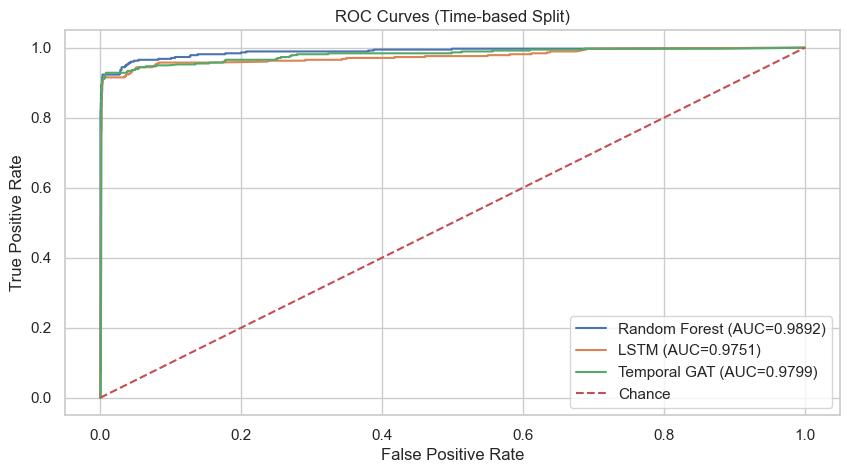

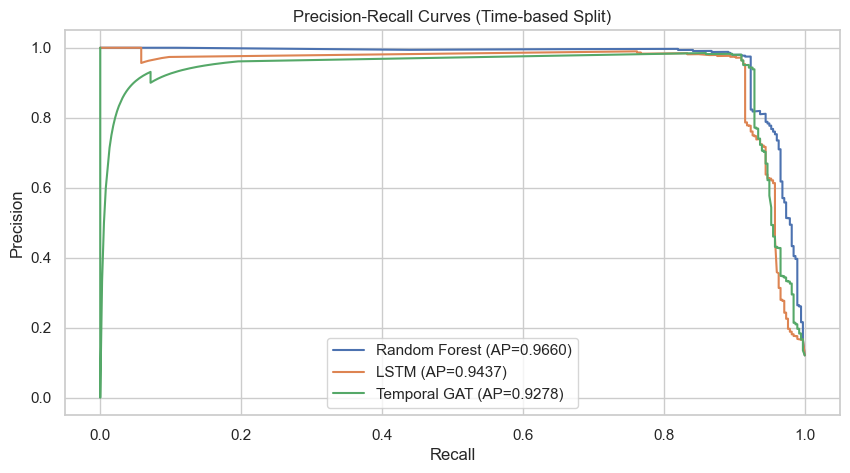

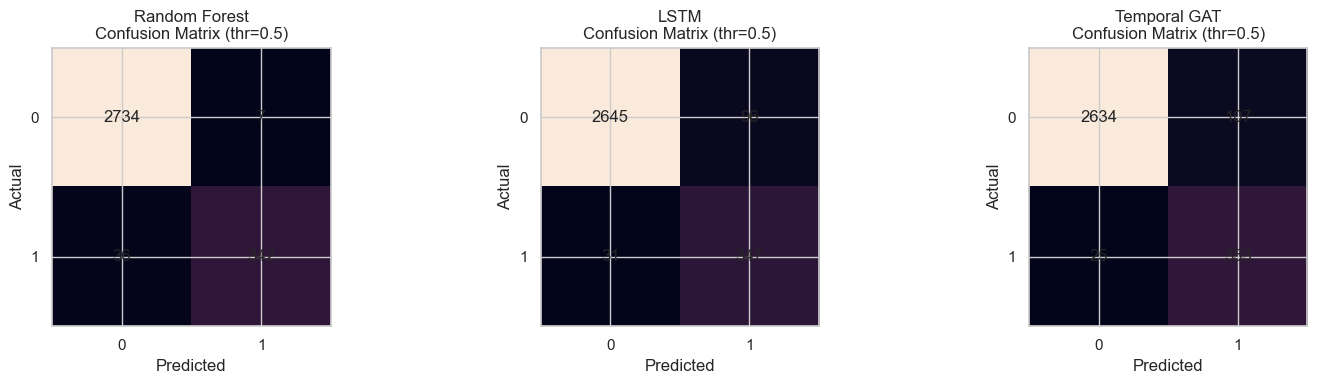

In [35]:
# ============================================================
# PLOTS: ROC, PR, Confusion Matrices (Time Split)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, confusion_matrix

y_true = y_test_ts.astype(int)

models = {
    "Random Forest": rf_probs_ts,
    "LSTM": lstm_probs_ts,
    "Temporal GAT": gat_probs_ts
}

# ---------------- ROC CURVE ----------------
plt.figure()
for name, probs in models.items():
    fpr, tpr, _ = roc_curve(y_true, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr,tpr):.4f})")
plt.plot([0,1], [0,1], linestyle="--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Time-based Split)")
plt.legend()
plt.show()

# ---------------- PR CURVE ----------------
plt.figure()
for name, probs in models.items():
    prec, rec, _ = precision_recall_curve(y_true, probs)
    ap = average_precision_score(y_true, probs)
    plt.plot(rec, prec, label=f"{name} (AP={ap:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves (Time-based Split)")
plt.legend()
plt.show()

# ---------------- CONFUSION MATRICES @ 0.5 ----------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, probs) in zip(axes, models.items()):
    pred = (probs >= 0.5).astype(int)
    cm = confusion_matrix(y_true, pred)
    ax.imshow(cm)
    ax.set_title(f"{name}\nConfusion Matrix (thr=0.5)")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    for (i,j), v in np.ndenumerate(cm):
        ax.text(j, i, str(v), ha="center", va="center")
plt.tight_layout()
plt.show()


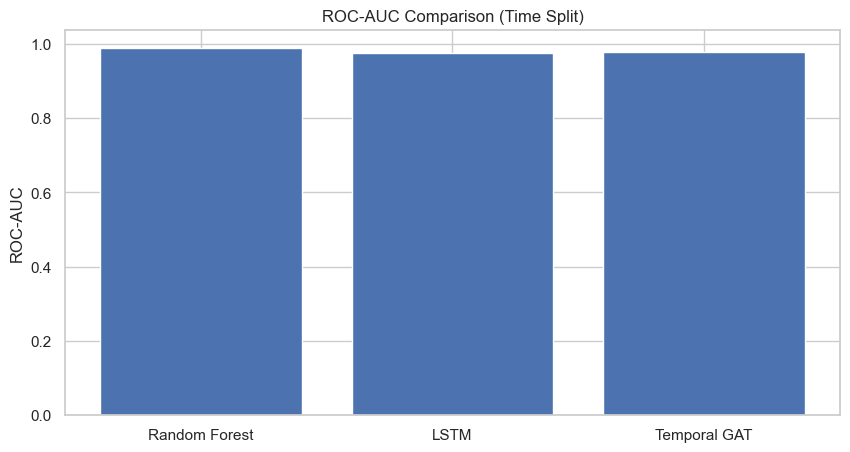

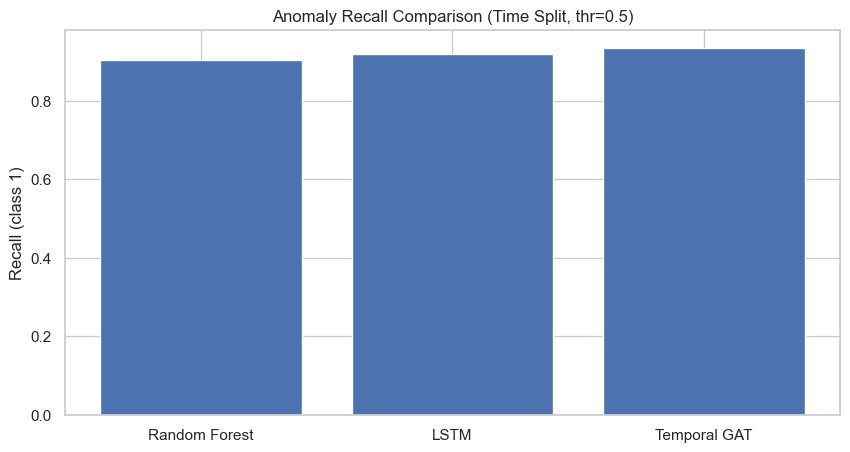

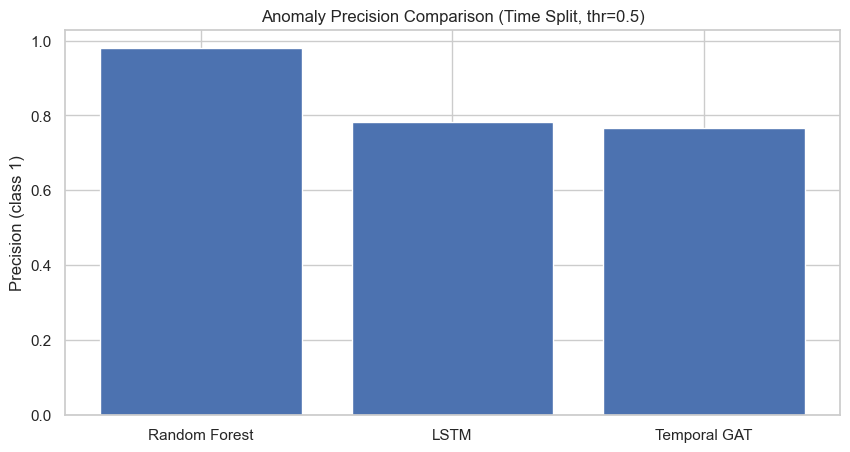

In [36]:
# ============================================================
# SUMMARY BAR CHARTS (Time Split)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, precision_score, recall_score

names = []
aucs = []
precs = []
recs = []

for name, probs in models.items():
    pred = (probs >= 0.5).astype(int)
    names.append(name)
    aucs.append(roc_auc_score(y_true, probs))
    precs.append(precision_score(y_true, pred, zero_division=0))
    recs.append(recall_score(y_true, pred, zero_division=0))

# AUC
plt.figure()
plt.bar(names, aucs)
plt.title("ROC-AUC Comparison (Time Split)")
plt.ylabel("ROC-AUC")
plt.show()

# Recall
plt.figure()
plt.bar(names, recs)
plt.title("Anomaly Recall Comparison (Time Split, thr=0.5)")
plt.ylabel("Recall (class 1)")
plt.show()

# Precision
plt.figure()
plt.bar(names, precs)
plt.title("Anomaly Precision Comparison (Time Split, thr=0.5)")
plt.ylabel("Precision (class 1)")
plt.show()
